# Smart City Traffic Intelligence

## 1. Setup and Load Raw Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")

In [3]:
df.shape

(48204, 9)

In [4]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB


In [6]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(17)

## 2. Initial Data Quality Checks

In [8]:
df["date_time"].dtype

<StringDtype(na_value=nan)>

In [9]:
df["date_time"].head()

0    2012-10-02 09:00:00
1    2012-10-02 10:00:00
2    2012-10-02 11:00:00
3    2012-10-02 12:00:00
4    2012-10-02 13:00:00
Name: date_time, dtype: str

In [10]:
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

In [11]:
df["date_time"].isna().sum()

np.int64(0)

In [12]:
df[["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]].describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [13]:
df[df["temp"] == 0].shape[0]

10

In [14]:
df[df["rain_1h"] > 100][
    ["date_time", "rain_1h", "weather_main", "weather_description", "traffic_volume"]
]

,date_time,rain_1h,weather_main,weather_description,traffic_volume
24872,2016-07-11 17:00:00,9831.3,Rain,very heavy rain,5535


In [15]:
df["rain_1h"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900     0.00000
0.950     0.30000
0.990     3.27000
0.995     5.92000
0.999    13.60346
Name: rain_1h, dtype: float64

In [16]:
Q1 = df["traffic_volume"].quantile(0.25)
Q3 = df["traffic_volume"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_bound, upper_bound

(np.float64(1193.0),
 np.float64(4933.0),
 np.float64(3740.0),
 np.float64(-4417.0),
 np.float64(10543.0))

In [17]:
df[
    (df["traffic_volume"] < lower_bound) |
    (df["traffic_volume"] > upper_bound)
].shape[0]

0

In [18]:
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [19]:
df["holiday"].value_counts(dropna=False)

holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [20]:
df["holiday"] = df["holiday"].fillna("No Holiday")


In [21]:
df = df.drop_duplicates().copy()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.shape

(48187, 9)

In [24]:
negative_traffic = (df["traffic_volume"] < 0).sum()
negative_traffic

np.int64(0)

In [25]:
df["traffic_volume"].isna().sum()

np.int64(0)

In [26]:
import numpy as np

df.loc[df["temp"] == 0, "temp"] = np.nan

In [27]:
df["temp"].isna().sum()

np.int64(10)

In [28]:
for col in ["rain_1h", "snow_1h", "clouds_all", "traffic_volume"]:
    print(col, (df[col] < 0).sum())

rain_1h 0
snow_1h 0
clouds_all 0
traffic_volume 0


In [29]:
df["month"] = df["date_time"].dt.month

In [30]:
df["temp"] = df.groupby("month")["temp"].transform(
    lambda x: x.fillna(x.median())
)

In [31]:
df["temp"].isna().sum()

np.int64(0)

In [32]:
for col in ["weather_main", "weather_description"]:
    df[col] = df[col].str.strip().str.lower()

In [33]:
df["weather_description"].value_counts().head(10)

weather_description
sky is clear        13384
mist                 5949
overcast clouds      5079
broken clouds        4663
scattered clouds     3460
light rain           3372
few clouds           1956
light snow           1945
moderate rain        1664
haze                 1360
Name: count, dtype: int64

In [34]:
df["year"] = df["date_time"].dt.year
df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["day_of_month"] = df["date_time"].dt.day

In [35]:
df["month_name"] = df["date_time"].dt.month_name()

In [36]:
df["is_weekend"] = df["day_of_week"] >= 5

In [37]:
df["day_type"] = df["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

In [38]:
df.isna().sum()

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
month                  0
year                   0
hour                   0
day_of_week            0
day_of_month           0
month_name             0
is_weekend             0
day_type               0
dtype: int64

In [39]:
df.shape

(48187, 17)

In [40]:
df["month_year"] = df["date_time"].dt.to_period("M").astype(str)

In [41]:
df.dtypes

holiday                           str
temp                          float64
rain_1h                       float64
snow_1h                       float64
clouds_all                      int64
weather_main                      str
weather_description               str
date_time              datetime64[us]
traffic_volume                  int64
month                           int32
year                            int32
hour                            int32
day_of_week                     int32
day_of_month                    int32
month_name                        str
is_weekend                       bool
day_type                          str
month_year                        str
dtype: object

In [42]:
cleaning_summary = {
    "rows": len(df),
    "columns": len(df.columns),
    "duplicate_rows": df.duplicated().sum(),
    "missing_values": df.isna().sum().sum(),
    "invalid_temperature_values": (df["temp"] == 0).sum()
}

cleaning_summary

{'rows': 48187,
 'columns': 18,
 'duplicate_rows': np.int64(0),
 'missing_values': np.int64(0),
 'invalid_temperature_values': np.int64(0)}

## 3. Part 2 Visualisations

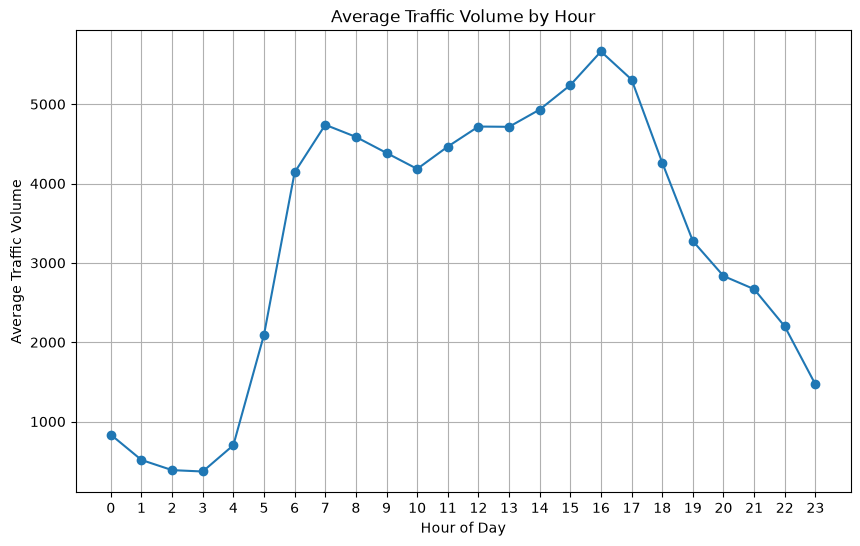

Saved to: C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\reports\average_traffic_by_hour.png


In [43]:
import matplotlib.pyplot as plt
from pathlib import Path

hourly_traffic = (
    df.groupby("hour")["traffic_volume"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.plot(
    hourly_traffic["hour"],
    hourly_traffic["traffic_volume"],
    marker="o"
)
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Hour")
plt.xticks(range(24))
plt.grid(True)

output_path = Path("../reports/average_traffic_by_hour.png")

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path.resolve()}")

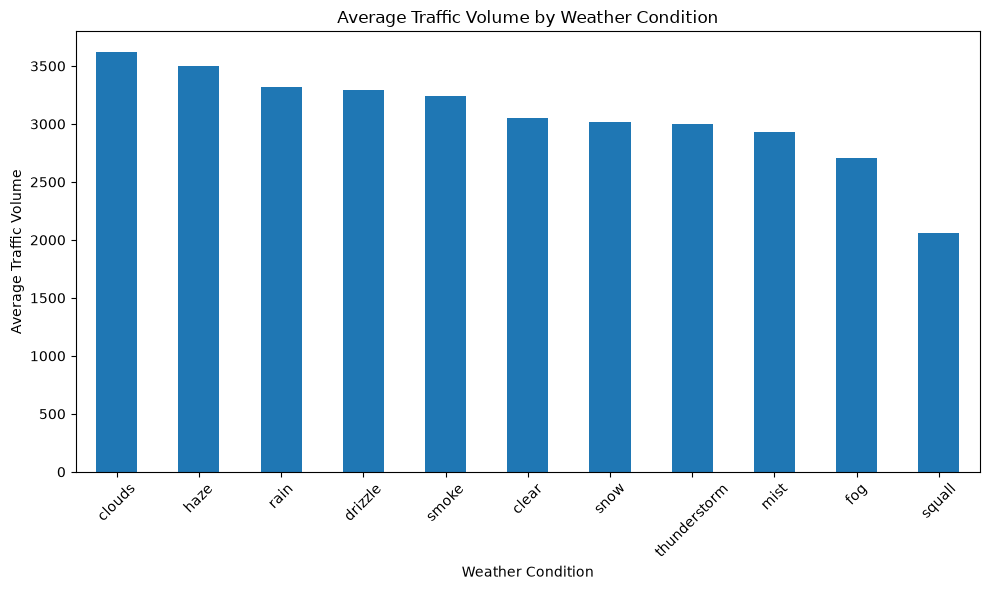

Saved to: C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\reports\average_traffic_by_weather.png


In [44]:
import matplotlib.pyplot as plt
from pathlib import Path

weather_traffic = (
    df.groupby("weather_main")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
weather_traffic.plot(kind="bar")

plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Weather Condition")
plt.xticks(rotation=45)
plt.tight_layout()

output_path = Path("../reports/average_traffic_by_weather.png")

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path.resolve()}")

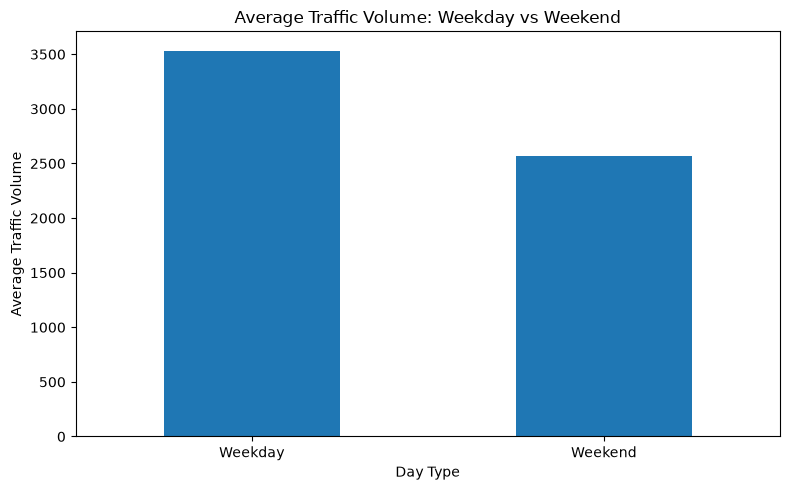

Saved to: C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\reports\average_traffic_by_day_type.png


In [45]:
daytype_traffic = (
    df.groupby("day_type")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
daytype_traffic.plot(kind="bar")

plt.xlabel("Day Type")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume: Weekday vs Weekend")
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path("../reports/average_traffic_by_day_type.png")

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path.resolve()}")

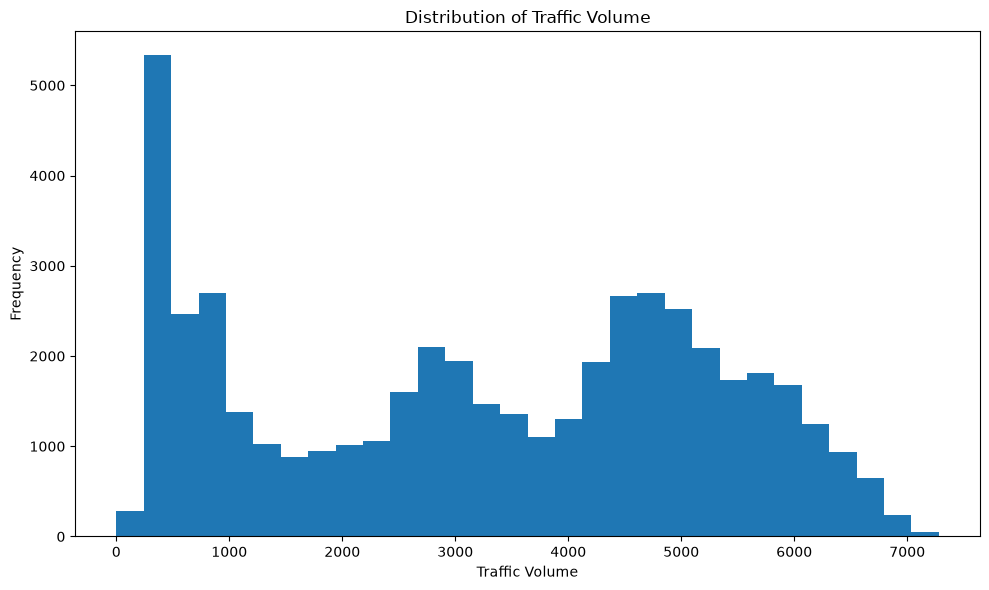

Saved to: C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\reports\traffic_volume_distribution.png


In [46]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(10, 6))
plt.hist(df["traffic_volume"], bins=30)

plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.title("Distribution of Traffic Volume")
plt.tight_layout()

output_path = Path("../reports/traffic_volume_distribution.png")

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {output_path.resolve()}")

## 4. Pipeline Validation and CLI Checks

In [47]:
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "pipeline.py",
        "validate",
        "--input",
        "../data/Metro_Interstate_Traffic_Volume.csv"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("\nOUTPUT:")
print(result.stdout)

print("\nERRORS:")
print(result.stderr)

Return code: 1

OUTPUT:


ERRORS:
  File "C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\part2_python\pipeline.py", line 313
    \n\nif __name__ == "__main__":
     ^
SyntaxError: unexpected character after line continuation character



In [48]:
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "pipeline.py",
        "clean",
        "--input",
        "../data/Metro_Interstate_Traffic_Volume.csv",
        "--output",
        "data/processed/cli_cleaned_traffic.csv"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("\nOUTPUT:")
print(result.stdout)

print("\nERRORS:")
print(result.stderr)

Return code: 1

OUTPUT:


ERRORS:
  File "C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\part2_python\pipeline.py", line 313
    \n\nif __name__ == "__main__":
     ^
SyntaxError: unexpected character after line continuation character



In [49]:
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "pipeline.py",
        "run",
        "--input",
        "../data/Metro_Interstate_Traffic_Volume.csv",
        "--output",
        "data/processed/cli_pipeline_output.csv"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("\nOUTPUT:")
print(result.stdout)

print("\nERRORS:")
print(result.stderr)

Return code: 1

OUTPUT:


ERRORS:
  File "C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\part2_python\pipeline.py", line 313
    \n\nif __name__ == "__main__":
     ^
SyntaxError: unexpected character after line continuation character



In [50]:
run_check = pd.read_csv("data/processed/cli_pipeline_output.csv")

print("Shape:", run_check.shape)
print("Missing values:", run_check.isna().sum().sum())
print("Duplicate rows:", run_check.duplicated().sum())

print("\nHoliday values:")
print(run_check["holiday"].value_counts(dropna=False).head(10))

Shape: (48187, 18)
Missing values: 0
Duplicate rows: 0

Holiday values:
holiday
No Holiday                   48126
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Name: count, dtype: int64


In [51]:
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "pipeline.py",
        "run",
        "--input",
        "../data/Metro_Interstate_Traffic_Volume.csv",
        "--output",
        "data/processed/final_pipeline_output.csv"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)

print("\n--- LOG OUTPUT ---")
print(result.stderr)

Return code: 1

--- LOG OUTPUT ---
  File "C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\part2_python\pipeline.py", line 313
    \n\nif __name__ == "__main__":
     ^
SyntaxError: unexpected character after line continuation character



## 5. Part 3 — Load Processed Data

In [52]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 3.0.3
numpy: 2.4.6
matplotlib: 3.11.0
scikit-learn: 1.9.0


In [53]:
import pandas as pd

ml_df = pd.read_csv(
    "data/processed/final_pipeline_output.csv"
)

print("Dataset loaded successfully.")
print("Shape:", ml_df.shape)

Dataset loaded successfully.
Shape: (48187, 18)


In [54]:
print(ml_df.head())

      holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0  No Holiday  288.28      0.0      0.0          40       clouds   
1  No Holiday  289.36      0.0      0.0          75       clouds   
2  No Holiday  289.58      0.0      0.0          90       clouds   
3  No Holiday  290.13      0.0      0.0          90       clouds   
4  No Holiday  291.14      0.0      0.0          75       clouds   

  weather_description            date_time  traffic_volume  month  year  hour  \
0    scattered clouds  2012-10-02 09:00:00            5545     10  2012     9   
1       broken clouds  2012-10-02 10:00:00            4516     10  2012    10   
2     overcast clouds  2012-10-02 11:00:00            4767     10  2012    11   
3     overcast clouds  2012-10-02 12:00:00            5026     10  2012    12   
4       broken clouds  2012-10-02 13:00:00            4918     10  2012    13   

   day_of_week  day_of_month month_name  is_weekend day_type month_year  
0            1             2  

In [55]:
print(ml_df.dtypes)

holiday                    str
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main               str
weather_description        str
date_time                  str
traffic_volume           int64
month                    int64
year                     int64
hour                     int64
day_of_week              int64
day_of_month             int64
month_name                 str
is_weekend                bool
day_type                   str
month_year                 str
dtype: object


## 6. Proxy Congestion and High-Risk Labels

In [56]:
# Calculate the traffic-volume quartiles
q1 = ml_df["traffic_volume"].quantile(0.25)
q2 = ml_df["traffic_volume"].quantile(0.50)
q3 = ml_df["traffic_volume"].quantile(0.75)

print("Q1:", q1)
print("Median:", q2)
print("Q3:", q3)

Q1: 1192.5
Median: 3379.0
Q3: 4933.0


In [57]:
def assign_congestion(volume):
    if volume <= q1:
        return "Low"
    elif volume <= q2:
        return "Moderate"
    elif volume <= q3:
        return "High"
    else:
        return "Severe"


ml_df["congestion_category"] = (
    ml_df["traffic_volume"]
    .apply(assign_congestion)
)

In [58]:
print(
    ml_df["congestion_category"]
    .value_counts()
    .sort_index()
)

congestion_category
High        12054
Low         12047
Moderate    12049
Severe      12037
Name: count, dtype: int64


In [59]:
SEVERE_WEATHER = [
    "rain",
    "thunderstorm",
    "fog",
    "mist",
    "snow",
    "haze"
]

ml_df["high_risk"] = (
    ml_df["congestion_category"].isin(["High", "Severe"])
    & ml_df["weather_main"].isin(SEVERE_WEATHER)
)

ml_df["high_risk"] = ml_df["high_risk"].astype(int)

In [60]:
print(ml_df["high_risk"].value_counts())

high_risk
0    39845
1     8342
Name: count, dtype: int64


In [61]:
print(
    ml_df["high_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

high_risk
0    82.69
1    17.31
Name: proportion, dtype: float64


In [62]:
print(
    pd.crosstab(
        ml_df["congestion_category"],
        ml_df["high_risk"]
    )
)

high_risk                0     1
congestion_category             
High                  7878  4176
Low                  12047     0
Moderate             12049     0
Severe                7871  4166


## 7. Supervised Learning — Classification

In [63]:
classification_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "weather_main"
]

X = ml_df[classification_features].copy()
y = ml_df["high_risk"].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (48187, 10)
Target shape: (48187,)

Features:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'weather_main']

Target distribution:
high_risk
0    39845
1     8342
Name: count, dtype: int64


In [64]:
# Machine-learning imports used throughout Part 3
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    r2_score
)


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = ["weather_main"]

numeric_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training features: (38549, 10)
Testing features: (9638, 10)

Training target:
high_risk
0    31876
1     6673
Name: count, dtype: int64

Testing target:
high_risk
0    7969
1    1669
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import StandardScaler

# Updated preprocessing
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Logistic Regression with scaling
logistic_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Train
logistic_model.fit(X_train, y_train)

# Predictions
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Logistic Regression Results - Scaled")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Logistic Regression Results - Scaled
----------------------------------------
Accuracy : 0.8756
Precision: 0.6528
Recall   : 0.6016
F1 Score : 0.6261
ROC AUC  : 0.9230


In [67]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
random_forest_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Predictions
rf_pred = random_forest_model.predict(X_test)
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_roc_auc:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.9851
Precision: 0.9305
Recall   : 0.9874
F1 Score : 0.9581
ROC AUC  : 0.9989


In [68]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.875597,0.652796,0.601558,0.62613,0.922966
1,Random Forest,0.985059,0.930548,0.987418,0.95814,0.998865


Confusion Matrix:
[[7846  123]
 [  21 1648]]


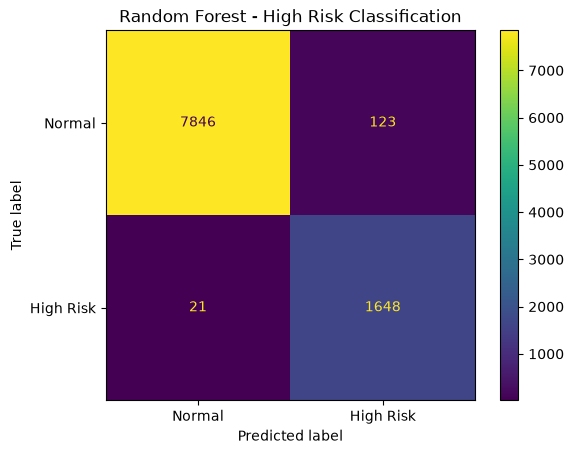

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "High Risk"]
)

disp.plot()
plt.title("Random Forest - High Risk Classification")
plt.show()

## 8. Supervised Learning — Regression

In [70]:
# Features for traffic-volume regression

regression_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "weather_main"
]

X_reg = ml_df[regression_features].copy()
y_reg = ml_df["traffic_volume"].copy()

print("Regression feature shape:", X_reg.shape)
print("Regression target shape:", y_reg.shape)

print("\nFeatures:")
print(X_reg.columns.tolist())

print("\nTraffic volume target:")
print(y_reg.describe())

Regression feature shape: (48187, 10)
Regression target shape: (48187,)

Features:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'weather_main']

Traffic volume target:
count    48187.000000
mean      3259.618134
std       1986.954465
min          0.000000
25%       1192.500000
50%       3379.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


In [71]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_reg_train.shape)
print("Testing features:", X_reg_test.shape)

print("\nTraining target:", y_reg_train.shape)
print("Testing target:", y_reg_test.shape)

Training features: (38549, 10)
Testing features: (9638, 10)

Training target: (38549,)
Testing target: (9638,)


In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Create Linear Regression pipeline
linear_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", LinearRegression())
])

# Train the model
linear_model.fit(X_reg_train, y_reg_train)

# Make predictions
linear_pred = linear_model.predict(X_reg_test)

# Evaluate
linear_mae = mean_absolute_error(y_reg_test, linear_pred)
linear_r2 = r2_score(y_reg_test, linear_pred)

print("Linear Regression Results")
print("-" * 35)
print(f"MAE: {linear_mae:.2f}")
print(f"R² : {linear_r2:.4f}")

Linear Regression Results
-----------------------------------
MAE: 1619.86
R² : -3.3021


In [73]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression pipeline
random_forest_reg_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
random_forest_reg_model.fit(X_reg_train, y_reg_train)

# Make predictions
rf_reg_pred = random_forest_reg_model.predict(X_reg_test)

# Evaluate
rf_reg_mae = mean_absolute_error(y_reg_test, rf_reg_pred)
rf_reg_r2 = r2_score(y_reg_test, rf_reg_pred)

print("Random Forest Regression Results")
print("-" * 40)
print(f"MAE: {rf_reg_mae:.2f}")
print(f"R² : {rf_reg_r2:.4f}")

Random Forest Regression Results
----------------------------------------
MAE: 210.22
R² : 0.9667


In [74]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_reg_mae
    ],
    "R2": [
        linear_r2,
        rf_reg_r2
    ]
})

regression_results

,Model,MAE,R2
0,Linear Regression,1619.864115,-3.302055
1,Random Forest,210.224325,0.966731


## 9. Unsupervised Learning — K-Means Clustering

In [75]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "traffic_volume",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week"
]

X_cluster = ml_df[cluster_features].copy()

# Scale the features
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Clustering data shape:", X_cluster.shape)
print("Scaled data shape:", X_cluster_scaled.shape)

Clustering data shape: (48187, 7)
Scaled data shape: (48187, 7)


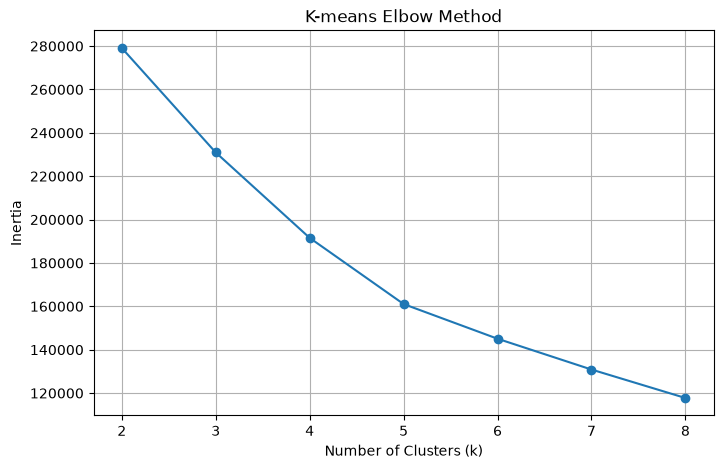

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different numbers of clusters
inertia = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means Elbow Method")
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

In [77]:
# Run K-means with 5 clusters

kmeans_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

# Add cluster labels to the dataset
ml_df["cluster"] = cluster_labels

print("Cluster counts:")
print(ml_df["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0    13470
1    19387
2        1
3    15309
4       20
Name: count, dtype: int64


In [78]:
cluster_profile = ml_df.groupby("cluster")[[
    "traffic_volume",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week"
]].mean().round(2)

cluster_counts = ml_df["cluster"].value_counts().sort_index()

cluster_profile["count"] = cluster_counts

cluster_profile

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,hour,day_of_week,count
cluster,,,,,,,,
0,816.96,278.57,0.16,0.00,43.70,3.03,3.39,13470
1,4197.14,279.67,0.18,0.00,83.41,14.48,2.76,19387
2,5535.00,302.11,9831.30,0.00,75.00,17.00,0.00,1
3,4220.93,285.65,0.05,0.00,11.18,14.85,2.92,15309
4,3654.75,271.64,0.20,0.36,90.00,16.55,1.75,20


In [79]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_cluster_scaled,
    cluster_labels
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.2347


## 10. Association Rule Mining

In [80]:
# Create categorical variables for association rule mining

association_df = ml_df.copy()

# Traffic category
association_df["traffic_level"] = pd.cut(
    association_df["traffic_volume"],
    bins=[-1, q1, q2, q3, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

# Temperature category
association_df["temperature_level"] = pd.cut(
    association_df["temp"],
    bins=[-float("inf"), 275, 290, float("inf")],
    labels=["Cold", "Mild", "Warm"]
)

# Time-of-day category
def time_period(hour):
    if 6 <= hour < 10:
        return "Morning Peak"
    elif 10 <= hour < 16:
        return "Daytime"
    elif 16 <= hour < 20:
        return "Evening Peak"
    else:
        return "Night"

association_df["time_period"] = association_df["hour"].apply(time_period)

# Weekend/weekday
association_df["day_category"] = association_df["is_weekend"].map({
    True: "Weekend",
    False: "Weekday"
})

print(
    association_df[
        [
            "traffic_level",
            "temperature_level",
            "time_period",
            "day_category",
            "weather_main"
        ]
    ].head()
)

  traffic_level temperature_level   time_period day_category weather_main
0        Severe              Mild  Morning Peak      Weekday       clouds
1          High              Mild       Daytime      Weekday       clouds
2          High              Mild       Daytime      Weekday       clouds
3        Severe              Warm       Daytime      Weekday       clouds
4          High              Warm       Daytime      Weekday       clouds


In [81]:
from mlxtend.preprocessing import TransactionEncoder

# Create transactions
transactions = []

for _, row in association_df.iterrows():
    transaction = [
        f"Traffic={row['traffic_level']}",
        f"Temperature={row['temperature_level']}",
        f"Time={row['time_period']}",
        f"Day={row['day_category']}",
        f"Weather={row['weather_main']}"
    ]
    transactions.append(transaction)

# Convert transactions into a one-hot encoded matrix
te = TransactionEncoder()

transaction_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

print("Transaction matrix shape:", transaction_df.shape)

print("\nFirst 5 rows:")
display(transaction_df.head())

Transaction matrix shape: (48187, 24)

First 5 rows:


,Day=Weekday,Day=Weekend,Temperature=Cold,Temperature=Mild,Temperature=Warm,Time=Daytime,Time=Evening Peak,Time=Morning Peak,Time=Night,Traffic=High,...,Weather=clouds,Weather=drizzle,Weather=fog,Weather=haze,Weather=mist,Weather=rain,Weather=smoke,Weather=snow,Weather=squall,Weather=thunderstorm
0,True,False,False,True,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
1,True,False,False,True,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
2,True,False,False,True,False,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
3,True,False,False,False,True,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,True,False,False,False,True,True,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False


In [82]:
from mlxtend.frequent_patterns import apriori

# Find frequent item combinations
frequent_itemsets = apriori(
    transaction_df,
    min_support=0.05,
    use_colnames=True
)

# Add the number of items in each combination
frequent_itemsets["item_count"] = frequent_itemsets["itemsets"].apply(len)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
).reset_index(drop=True)

print("Number of frequent itemsets:", len(frequent_itemsets))

display(frequent_itemsets.head(15))

Number of frequent itemsets: 147


,support,itemsets,item_count
0,0.715691,frozenset({Day=Weekday}),1
1,0.420777,frozenset({Time=Night}),1
2,0.345446,frozenset({Temperature=Mild}),1
3,0.339635,frozenset({Temperature=Cold}),1
4,0.314919,frozenset({Temperature=Warm}),1
5,0.314566,frozenset({Weather=clouds}),1
6,0.301243,"frozenset({Day=Weekday, Time=Night})",2
7,0.284309,frozenset({Day=Weekend}),1
8,0.277751,frozenset({Weather=clear}),1
9,0.250150,frozenset({Traffic=High}),1


In [83]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

# Keep useful columns
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    "lift",
    ascending=False
).reset_index(drop=True)

print("Number of association rules:", len(rules))

display(rules.head(15))

Number of association rules: 98


,antecedents,consequents,support,confidence,lift
0,"frozenset({Day=Weekday, Time=Morning Peak})",frozenset({Traffic=Severe}),0.100318,0.821690,3.289421
1,"frozenset({Time=Daytime, Day=Weekend})",frozenset({Traffic=High}),0.055720,0.804374,3.215560
2,frozenset({Weather=snow}),frozenset({Temperature=Cold}),0.056488,0.946783,2.787646
3,frozenset({Time=Morning Peak}),"frozenset({Day=Weekday, Traffic=Severe})",0.100318,0.584947,2.427179
4,"frozenset({Time=Night, Temperature=Cold})",frozenset({Traffic=Low}),0.090626,0.600357,2.401380
5,"frozenset({Day=Weekday, Temperature=Mild, Traf...",frozenset({Time=Night}),0.065433,0.994637,2.363809
6,"frozenset({Temperature=Mild, Time=Night})",frozenset({Traffic=Low}),0.091456,0.590039,2.360106
7,"frozenset({Day=Weekday, Weather=clear, Traffic...",frozenset({Time=Night}),0.052379,0.992919,2.359725
8,"frozenset({Day=Weekday, Traffic=Low})",frozenset({Time=Night}),0.167431,0.990790,2.354665
9,"frozenset({Day=Weekday, Traffic=High})",frozenset({Time=Daytime}),0.086994,0.574247,2.347804


In [84]:
# Save association rules
rules_output = rules.copy()

# Convert frozensets to readable text
rules_output["antecedents"] = rules_output["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules_output["consequents"] = rules_output["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

# Save to CSV
rules_output.to_csv(
    "data/processed/association_rules.csv",
    index=False
)

print("Association rules saved successfully.")
print("File: data/processed/association_rules.csv")

display(rules_output.head(10))

Association rules saved successfully.
File: data/processed/association_rules.csv


,antecedents,consequents,support,confidence,lift
0,"Day=Weekday, Time=Morning Peak",Traffic=Severe,0.100318,0.821690,3.289421
1,"Day=Weekend, Time=Daytime",Traffic=High,0.055720,0.804374,3.215560
2,Weather=snow,Temperature=Cold,0.056488,0.946783,2.787646
3,Time=Morning Peak,"Day=Weekday, Traffic=Severe",0.100318,0.584947,2.427179
4,"Temperature=Cold, Time=Night",Traffic=Low,0.090626,0.600357,2.401380
5,"Day=Weekday, Temperature=Mild, Traffic=Low",Time=Night,0.065433,0.994637,2.363809
6,"Temperature=Mild, Time=Night",Traffic=Low,0.091456,0.590039,2.360106
7,"Day=Weekday, Traffic=Low, Weather=clear",Time=Night,0.052379,0.992919,2.359725
8,"Day=Weekday, Traffic=Low",Time=Night,0.167431,0.990790,2.354665
9,"Day=Weekday, Traffic=High",Time=Daytime,0.086994,0.574247,2.347804


## 11. Deep Learning — Neural Network

In [85]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

neural_network_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42,
        early_stopping=True
    ))
])

neural_network_model.fit(X_train, y_train)

nn_predictions = neural_network_model.predict(X_test)
nn_probabilities = neural_network_model.predict_proba(X_test)[:, 1]

print("Neural Network model trained successfully.")

Neural Network model trained successfully.


In [86]:
nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_precision = precision_score(y_test, nn_predictions)
nn_recall = recall_score(y_test, nn_predictions)
nn_f1 = f1_score(y_test, nn_predictions)
nn_roc_auc = roc_auc_score(y_test, nn_probabilities)

print("Neural Network Results")
print("----------------------")
print(f"Accuracy : {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall   : {nn_recall:.4f}")
print(f"F1 Score : {nn_f1:.4f}")
print(f"ROC AUC  : {nn_roc_auc:.4f}")

Neural Network Results
----------------------
Accuracy : 0.9850
Precision: 0.9509
Recall   : 0.9629
F1 Score : 0.9568
ROC AUC  : 0.9974


In [87]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        0.875597,
        0.985059,
        nn_accuracy
    ],
    "Precision": [
        0.652796,
        0.930548,
        nn_precision
    ],
    "Recall": [
        0.601558,
        0.987418,
        nn_recall
    ],
    "F1 Score": [
        0.626130,
        0.958140,
        nn_f1
    ],
    "ROC AUC": [
        0.922966,
        0.998865,
        nn_roc_auc
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.875597,0.652796,0.601558,0.626130,0.922966
1,Random Forest,0.985059,0.930548,0.987418,0.958140,0.998865
2,Neural Network,0.984955,0.950888,0.962852,0.956832,0.997378


In [88]:
classification_results.to_csv(
    "data/processed/classification_model_results.csv",
    index=False
)

print("Classification results saved successfully.")

Classification results saved successfully.


## 12. Explainable AI — SHAP

In [89]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [90]:
# Get the fitted preprocessing transformer
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get the fitted Random Forest classifier
rf_classifier = random_forest_model.named_steps["classifier"]

# Transform the test data
X_test_transformed = rf_preprocessor.transform(X_test)

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

print("Transformed test data shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed test data shape: (9638, 20)
Number of feature names: 20


In [91]:
# Create SHAP explainer for the Random Forest
explainer = shap.TreeExplainer(rf_classifier)

# Use a sample of the test data to keep SHAP calculation fast
sample_size = min(1000, X_test_transformed.shape[0])
X_shap = X_test_transformed[:sample_size]

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP calculation completed.")
print("Sample size:", sample_size)

SHAP calculation completed.
Sample size: 1000


## 13. Key Outputs and Next Steps

In [92]:
# SHAP Feature Importance
# Compatible with the current SHAP output format

print("SHAP values shape:", np.shape(shap_values))

# For binary classification, select the positive-class SHAP values
if isinstance(shap_values, list):
    shap_positive = shap_values[1]
else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Select class 1 (high-risk)
        shap_positive = shap_array[:, :, 1]
    else:
        shap_positive = shap_array

print("Positive-class SHAP shape:", shap_positive.shape)

# Calculate mean absolute SHAP importance
shap_importance = np.abs(shap_positive).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": shap_importance
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

shap_importance_df.head(10)

SHAP values shape: (1000, 20, 2)
Positive-class SHAP shape: (1000, 20)


,Feature,Mean Absolute SHAP
4,num__hour,0.194506
10,cat__weather_main_clouds,0.162169
9,cat__weather_main_clear,0.107139
15,cat__weather_main_rain,0.044911
14,cat__weather_main_mist,0.038082
3,num__clouds_all,0.034152
5,num__day_of_week,0.021064
11,cat__weather_main_drizzle,0.021058
17,cat__weather_main_snow,0.018657
8,num__is_weekend,0.018523


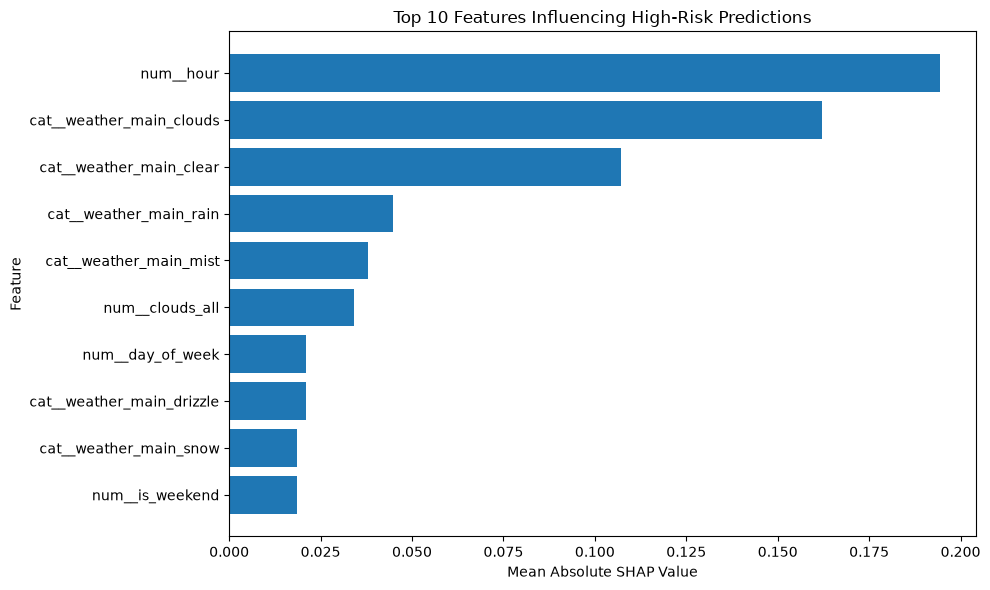

In [93]:
plt.figure(figsize=(10, 6))

top_features = shap_importance_df.head(10).sort_values(
    "Mean Absolute SHAP"
)

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing High-Risk Predictions")

plt.tight_layout()

plt.savefig(
    "../reports/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

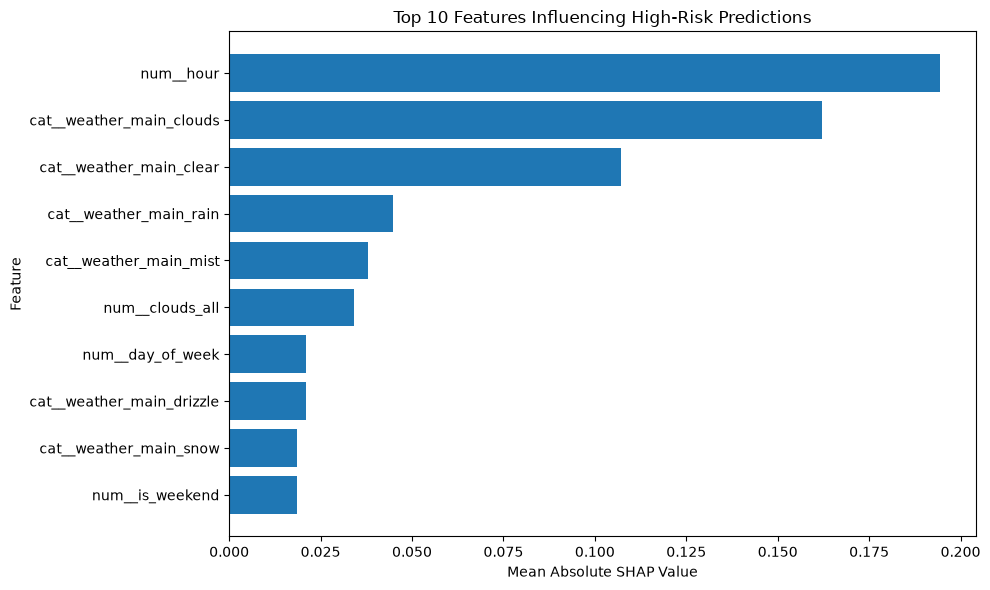

SHAP feature-importance plot saved successfully.
File: reports/shap_feature_importance.png


In [94]:
plt.figure(figsize=(10, 6))

top_features = shap_importance_df.head(10).sort_values(
    "Mean Absolute SHAP"
)

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing High-Risk Predictions")

plt.tight_layout()

plt.savefig(
    "../reports/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP feature-importance plot saved successfully.")
print("File: reports/shap_feature_importance.png")

In [95]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [96]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [97]:
import mlflow
import mlflow.sklearn

# Create/select an MLflow experiment
mlflow.set_experiment("Smart City Traffic Intelligence")

print("MLflow experiment created/selected successfully.")

MLflow experiment created/selected successfully.


In [98]:
with mlflow.start_run(run_name="Random_Forest_Classification"):

    # Log model parameters
    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)

    # Log classification metrics
    mlflow.log_metric("accuracy", 0.985059)
    mlflow.log_metric("precision", 0.930548)
    mlflow.log_metric("recall", 0.987418)
    mlflow.log_metric("f1_score", 0.958140)
    mlflow.log_metric("roc_auc", 0.998865)

    # Log the trained model
    mlflow.sklearn.log_model(
        random_forest_model,
        name="random_forest_classification_model"
    )

print("Random Forest experiment logged successfully.")

Random Forest experiment logged successfully.


C:\Users\akash\anaconda3\Lib\site-packages\mlflow\utils\file_utils.py:304: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
  with codecs.open(filename, mode="w", encoding=ENCODING) as handle:


In [99]:
runs = mlflow.search_runs(
    experiment_names=["Smart City Traffic Intelligence"]
)

runs[[
    "run_id",
    "status",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1_score",
    "metrics.roc_auc"
]]

,run_id,status,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1_score,metrics.roc_auc
0,cf6f2c8a6d384073932c62b5f4a88489,FINISHED,0.985059,0.930548,0.987418,0.95814,0.998865
1,bcd1150f5cb7414db1af437c56ef7639,FINISHED,0.985059,0.930548,0.987418,0.95814,0.998865
2,9e5f142ff498411e954cec8f1c7cee97,FINISHED,0.985059,0.930548,0.987418,0.95814,0.998865


In [100]:
mlflow_run_info = runs[[
    "run_id",
    "status",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1_score",
    "metrics.roc_auc"
]]

mlflow_run_info.to_csv(
    "data/processed/mlflow_classification_run.csv",
    index=False
)

print("MLflow run information saved successfully.")
print("File: data/processed/mlflow_classification_run.csv")

MLflow run information saved successfully.
File: data/processed/mlflow_classification_run.csv


In [101]:
import fastapi

print("FastAPI version:", fastapi.__version__)

FastAPI version: 0.141.1


In [102]:
import joblib

joblib.dump(
    random_forest_model,
    "data/processed/random_forest_classification_model.joblib"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [103]:
from pathlib import Path

model_path = Path(
    "data/processed/random_forest_classification_model.joblib"
)

print("Model exists:", model_path.exists())
print("Model path:", model_path)

Model exists: True
Model path: data\processed\random_forest_classification_model.joblib


In [104]:
from pathlib import Path

app_path = Path("app.py")

print("app.py exists:", app_path.exists())
print("app.py size:", app_path.stat().st_size, "bytes")

app.py exists: True
app.py size: 2201 bytes


In [105]:
from scipy.stats import ks_2samp

# Numeric features used by the classification model
monitoring_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "day_of_month",
    "month"
]

# Reference data: training set
reference_data = X_train[monitoring_features].copy()

# Current data: test set
current_data = X_test[monitoring_features].copy()

print("Reference data shape:", reference_data.shape)
print("Current data shape:", current_data.shape)

Reference data shape: (38549, 8)
Current data shape: (9638, 8)


In [106]:
drift_results = []

for feature in monitoring_features:
    statistic, p_value = ks_2samp(
        reference_data[feature],
        current_data[feature]
    )

    drift_results.append({
        "Feature": feature,
        "KS Statistic": statistic,
        "p-value": p_value,
        "Status": "ALERT" if p_value < 0.05 else "PASS"
    })

drift_results_df = pd.DataFrame(drift_results)

drift_results_df

,Feature,KS Statistic,p-value,Status
0,temp,0.006273,0.920071,PASS
1,rain_1h,0.002621,1.000000,PASS
2,snow_1h,0.000181,1.000000,PASS
3,clouds_all,0.005269,0.982265,PASS
4,hour,0.011760,0.234870,PASS
5,day_of_week,0.007982,0.706692,PASS
6,day_of_month,0.008322,0.656489,PASS
7,month,0.011471,0.260351,PASS


In [107]:
# Overall monitoring status

alert_count = (drift_results_df["Status"] == "ALERT").sum()
pass_count = (drift_results_df["Status"] == "PASS").sum()

overall_status = "ALERT" if alert_count > 0 else "PASS"

print("Smart City Traffic Intelligence - Data Drift Monitoring")
print("--------------------------------------------------------")
print(f"Features monitored: {len(drift_results_df)}")
print(f"PASS: {pass_count}")
print(f"ALERT: {alert_count}")
print(f"Overall status: {overall_status}")

Smart City Traffic Intelligence - Data Drift Monitoring
--------------------------------------------------------
Features monitored: 8
PASS: 8
ALERT: 0
Overall status: PASS


In [108]:
drift_results_df.to_csv(
    "data/processed/drift_monitoring_results.csv",
    index=False
)

print("Drift monitoring results saved successfully.")
print("File: data/processed/drift_monitoring_results.csv")

Drift monitoring results saved successfully.
File: data/processed/drift_monitoring_results.csv


In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get predictions for the complete test set
rf_test_predictions = random_forest_model.predict(X_test)

# Create a test-set copy with the relevant grouping variable
fairness_test = X_test.copy()
fairness_test["actual"] = y_test.values
fairness_test["predicted"] = rf_test_predictions

# Calculate performance by day type
fairness_results = []

for group_name, group_data in fairness_test.groupby("is_weekend"):

    fairness_results.append({
        "Group": "Weekend" if group_name else "Weekday",
        "Observations": len(group_data),
        "Accuracy": accuracy_score(
            group_data["actual"],
            group_data["predicted"]
        ),
        "Precision": precision_score(
            group_data["actual"],
            group_data["predicted"],
            zero_division=0
        ),
        "Recall": recall_score(
            group_data["actual"],
            group_data["predicted"],
            zero_division=0
        ),
        "F1 Score": f1_score(
            group_data["actual"],
            group_data["predicted"],
            zero_division=0
        )
    })

fairness_results_df = pd.DataFrame(fairness_results)

fairness_results_df

,Group,Observations,Accuracy,Precision,Recall,F1 Score
0,Weekday,6928,0.989174,0.957153,0.990701,0.973638
1,Weekend,2710,0.974539,0.811728,0.970480,0.884034


In [110]:
# Calculate fairness/performance gaps

weekday = fairness_results_df[
    fairness_results_df["Group"] == "Weekday"
].iloc[0]

weekend = fairness_results_df[
    fairness_results_df["Group"] == "Weekend"
].iloc[0]

fairness_gaps = {
    "Accuracy Gap": weekday["Accuracy"] - weekend["Accuracy"],
    "Precision Gap": weekday["Precision"] - weekend["Precision"],
    "Recall Gap": weekday["Recall"] - weekend["Recall"],
    "F1 Score Gap": weekday["F1 Score"] - weekend["F1 Score"]
}

for metric, gap in fairness_gaps.items():
    print(f"{metric}: {gap:.4f}")

Accuracy Gap: 0.0146
Precision Gap: 0.1454
Recall Gap: 0.0202
F1 Score Gap: 0.0896


In [111]:
prediction_rates = (
    fairness_test
    .groupby("is_weekend")["predicted"]
    .mean()
    .reset_index()
)

prediction_rates["Group"] = prediction_rates["is_weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

prediction_rates["High Risk Prediction Rate"] = (
    prediction_rates["predicted"] * 100
)

prediction_rates[[
    "Group",
    "High Risk Prediction Rate"
]]

,Group,High Risk Prediction Rate
0,Weekday,20.886259
1,Weekend,11.955720


In [112]:
# Save Responsible AI / fairness analysis

fairness_results_df.to_csv(
    "data/processed/fairness_performance_results.csv",
    index=False
)

prediction_rates[[
    "Group",
    "High Risk Prediction Rate"
]].to_csv(
    "data/processed/fairness_prediction_rates.csv",
    index=False
)

print("Responsible AI analysis saved successfully.")
print("Files:")
print("- data/processed/fairness_performance_results.csv")
print("- data/processed/fairness_prediction_rates.csv")

Responsible AI analysis saved successfully.
Files:
- data/processed/fairness_performance_results.csv
- data/processed/fairness_prediction_rates.csv


In [113]:
responsible_ai_summary = """
Responsible AI and Fairness Analysis
=====================================

The Random Forest classification model was evaluated separately
for weekday and weekend observations.

Weekday performance:
- Accuracy: 98.92%
- Precision: 95.72%
- Recall: 99.07%
- F1 Score: 97.36%

Weekend performance:
- Accuracy: 97.45%
- Precision: 81.17%
- Recall: 97.05%
- F1 Score: 88.40%

High-risk prediction rate:
- Weekday: 20.89%
- Weekend: 11.96%

Key finding:
Model performance is stronger for weekday observations.
Weekend precision and F1 score are lower, indicating that
prediction errors are not evenly distributed across day types.

Limitation:
The high-risk target is a proxy label created from congestion
and selected weather conditions. It does not represent actual
accident outcomes. Therefore, this fairness analysis evaluates
performance against the proxy target rather than real-world
accident risk.

Governance consideration:
The model should not be treated as definitive accident-risk
evidence. Results should be monitored across day types and
re-evaluated when new data becomes available.
"""

with open(
    "reports/responsible_ai_fairness_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(responsible_ai_summary)

print("Responsible AI report saved successfully.")
print("File: reports/responsible_ai_fairness_report.txt")

Responsible AI report saved successfully.
File: reports/responsible_ai_fairness_report.txt


In [114]:
# Traffic timing recommendation analysis

recommendation_by_hour = (
    ml_df.groupby("hour")["traffic_volume"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

recommendation_by_hour.columns = [
    "Hour",
    "Average Traffic",
    "Median Traffic",
    "Observations"
]

recommendation_by_hour = recommendation_by_hour.sort_values(
    "Average Traffic"
)

print("Lowest-traffic periods:")
display(recommendation_by_hour.head(10))

Lowest-traffic periods:


,Hour,Average Traffic,Median Traffic,Observations
3,3,371.090864,362.0,2025
2,2,388.353640,315.0,2019
1,1,516.339033,420.0,2047
4,4,702.551889,807.0,2091
0,0,834.984774,676.0,2036
23,23,1469.135294,1250.0,2040
5,5,2094.573437,2638.0,2063
22,22,2199.405717,2050.5,1994
21,21,2668.940464,2649.0,1982
20,20,2834.667509,2866.0,1979


In [115]:
traffic_by_hour_day = (
    ml_df.groupby(["hour", "day_type"])["traffic_volume"]
    .mean()
    .reset_index()
)

traffic_by_hour_day.columns = [
    "Hour",
    "Day Type",
    "Average Traffic"
]

traffic_by_hour_day = traffic_by_hour_day.sort_values(
    "Average Traffic"
)

display(traffic_by_hour_day.head(15))

,Hour,Day Type,Average Traffic
4,2,Weekday,301.982818
6,3,Weekday,362.289835
9,4,Weekend,375.420168
7,3,Weekend,393.611599
2,1,Weekday,396.913043
5,2,Weekend,611.171986
11,5,Weekend,639.237232
0,0,Weekday,651.686903
3,1,Weekend,805.717391
8,4,Weekday,832.661096


In [116]:
traffic_by_weather = (
    ml_df.groupby("weather_main")["traffic_volume"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

traffic_by_weather.columns = [
    "Weather",
    "Average Traffic",
    "Median Traffic",
    "Observations"
]

traffic_by_weather = traffic_by_weather.sort_values(
    "Average Traffic"
)

display(traffic_by_weather)

,Weather,Average Traffic,Median Traffic,Observations
9,squall,2061.750000,1818.0,4
3,fog,2703.720395,2339.0,912
5,mist,2933.343923,2800.0,5949
10,thunderstorm,2999.431752,2969.0,1033
8,snow,3016.321391,3080.0,2875
0,clear,3055.614465,3044.0,13384
7,smoke,3237.650000,3612.0,20
2,drizzle,3292.189560,3475.0,1820
6,rain,3317.905501,3497.5,5672
4,haze,3502.101471,3987.0,1360


In [117]:
# Practical travel recommendations by time, day type and weather

recommendation_analysis = (
    ml_df.groupby(
        ["hour", "day_type", "weather_main"]
    )["traffic_volume"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

recommendation_analysis.columns = [
    "Hour",
    "Day Type",
    "Weather",
    "Average Traffic",
    "Median Traffic",
    "Observations"
]

# Only use combinations with at least 50 observations
reliable_recommendations = recommendation_analysis[
    recommendation_analysis["Observations"] >= 50
].copy()

reliable_recommendations = reliable_recommendations.sort_values(
    "Average Traffic"
)

display(reliable_recommendations.head(15))

,Hour,Day Type,Weather,Average Traffic,Median Traffic,Observations
39,2,Weekday,drizzle,292.355932,280.0,59
42,2,Weekday,mist,294.387387,281.0,222
43,2,Weekday,rain,299.301676,286.0,179
38,2,Weekday,clouds,300.093842,286.0,341
44,2,Weekday,snow,306.010989,275.0,91
37,2,Weekday,clear,307.010941,295.0,457
59,3,Weekday,drizzle,354.735849,353.0,53
64,3,Weekday,snow,358.760870,343.0,92
58,3,Weekday,clouds,358.909375,354.0,320
91,4,Weekend,rain,359.576271,371.0,59


In [118]:
# Find average traffic by hour and day type

hour_day_summary = (
    ml_df.groupby(["hour", "day_type"])["traffic_volume"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

hour_day_summary.columns = [
    "Hour",
    "Day Type",
    "Average Traffic",
    "Median Traffic",
    "Observations"
]

# Sort by hour first
hour_day_summary = hour_day_summary.sort_values(
    ["Hour", "Day Type"]
)

display(hour_day_summary)

,Hour,Day Type,Average Traffic,Median Traffic,Observations
0,0,Weekday,651.686903,617.0,1466
1,0,Weekend,1306.414035,1290.0,570
2,1,Weekday,396.913043,378.0,1449
3,1,Weekend,805.717391,791.0,598
4,2,Weekday,301.982818,287.0,1455
5,2,Weekend,611.171986,604.0,564
6,3,Weekday,362.289835,355.0,1456
7,3,Weekend,393.611599,389.0,569
8,4,Weekday,832.661096,847.5,1496
9,4,Weekend,375.420168,376.0,595


In [119]:
# High-risk rate by hour and day type

risk_by_time = (
    ml_df.groupby(["hour", "day_type"])["high_risk"]
    .agg(["mean", "count"])
    .reset_index()
)

risk_by_time["High Risk Rate (%)"] = risk_by_time["mean"] * 100

risk_by_time = risk_by_time.drop(columns=["mean"])

risk_by_time.columns = [
    "Hour",
    "Day Type",
    "Observations",
    "High Risk Rate (%)"
]

risk_by_time = risk_by_time.sort_values(
    ["High Risk Rate (%)", "Observations"]
)

display(risk_by_time.head(15))

,Hour,Day Type,Observations,High Risk Rate (%)
5,2,Weekend,564,0.00000
7,3,Weekend,569,0.00000
1,0,Weekend,570,0.00000
9,4,Weekend,595,0.00000
3,1,Weekend,598,0.00000
13,6,Weekend,598,0.00000
15,7,Weekend,604,0.00000
11,5,Weekend,607,0.00000
2,1,Weekday,1449,0.00000
4,2,Weekday,1455,0.00000


In [120]:
# Final recommendation summary

recommended_hours = [2, 3, 4]

final_recommendation = (
    ml_df[ml_df["hour"].isin(recommended_hours)]
    .groupby(["hour", "day_type"])
    .agg(
        Average_Traffic=("traffic_volume", "mean"),
        Median_Traffic=("traffic_volume", "median"),
        High_Risk_Rate=("high_risk", "mean"),
        Observations=("traffic_volume", "count")
    )
    .reset_index()
)

final_recommendation["High_Risk_Rate"] = (
    final_recommendation["High_Risk_Rate"] * 100
)

display(final_recommendation)

,hour,day_type,Average_Traffic,Median_Traffic,High_Risk_Rate,Observations
0,2,Weekday,301.982818,287.0,0.0,1455
1,2,Weekend,611.171986,604.0,0.0,564
2,3,Weekday,362.289835,355.0,0.0,1456
3,3,Weekend,393.611599,389.0,0.0,569
4,4,Weekday,832.661096,847.5,0.0,1496
5,4,Weekend,375.420168,376.0,0.0,595


In [121]:
# Save recommendation analysis

final_recommendation.to_csv(
    "data/processed/traffic_timing_recommendations.csv",
    index=False
)

print("Recommendation results saved successfully.")

Recommendation results saved successfully.


In [122]:
print(
    "File saved:",
    "data/processed/traffic_timing_recommendations.csv"
)

File saved: data/processed/traffic_timing_recommendations.csv


In [123]:
recommendation_text = """
Traffic Timing Recommendation

The analysis indicates that traffic volume is generally lowest during
the early morning hours, particularly around 2 AM to 4 AM on weekdays.

The lowest observed average traffic volume was approximately 302 vehicles
per hour at 2 AM on weekdays, followed by approximately 362 vehicles per
hour at 3 AM. At 4 AM on weekdays, average traffic was approximately
833 vehicles per hour.

The selected early-morning periods also showed a 0% high-risk proxy rate
in the analysed data. However, the high-risk measure is a proxy based on
congestion and selected severe-weather categories rather than actual
accident records.

Therefore, when travel timing is flexible and operationally appropriate,
early-morning weekday periods may provide lower congestion. The
recommendation should not be interpreted as a guarantee of road safety,
and weather and real-world operating conditions should still be considered.
"""

print(recommendation_text)


Traffic Timing Recommendation

The analysis indicates that traffic volume is generally lowest during
the early morning hours, particularly around 2 AM to 4 AM on weekdays.

The lowest observed average traffic volume was approximately 302 vehicles
per hour at 2 AM on weekdays, followed by approximately 362 vehicles per
hour at 3 AM. At 4 AM on weekdays, average traffic was approximately
833 vehicles per hour.

The selected early-morning periods also showed a 0% high-risk proxy rate
in the analysed data. However, the high-risk measure is a proxy based on
congestion and selected severe-weather categories rather than actual
accident records.

Therefore, when travel timing is flexible and operationally appropriate,
early-morning weekday periods may provide lower congestion. The
recommendation should not be interpreted as a guarantee of road safety,
and weather and real-world operating conditions should still be considered.



In [124]:
from pathlib import Path

report_path = Path("reports/traffic_timing_recommendation.txt")

report_path.write_text(
    recommendation_text,
    encoding="utf-8"
)

print(f"Recommendation report saved to: {report_path}")

Recommendation report saved to: reports\traffic_timing_recommendation.txt


In [125]:
from pathlib import Path

processed_dir = Path("data/processed")
reports_dir = Path("reports")

print("=== Part 3 Processed Files ===")

for file in sorted(processed_dir.iterdir()):
    if file.is_file():
        print("✓", file.name)

print("\n=== Part 3 Report Files ===")

for file in sorted(reports_dir.iterdir()):
    if file.is_file():
        print("✓", file.name)

=== Part 3 Processed Files ===
✓ association_rules.csv
✓ classification_model_results.csv
✓ cli_cleaned_traffic.csv
✓ cli_pipeline_output.csv
✓ drift_monitoring_results.csv
✓ fairness_performance_results.csv
✓ fairness_prediction_rates.csv
✓ final_pipeline_output.csv
✓ mlflow_classification_run.csv
✓ random_forest_classification_model.joblib
✓ traffic_timing_recommendations.csv

=== Part 3 Report Files ===
✓ fastapi_test_result.txt
✓ responsible_ai_fairness_report.txt
✓ shap_feature_importance.png
✓ traffic_timing_recommendation.txt


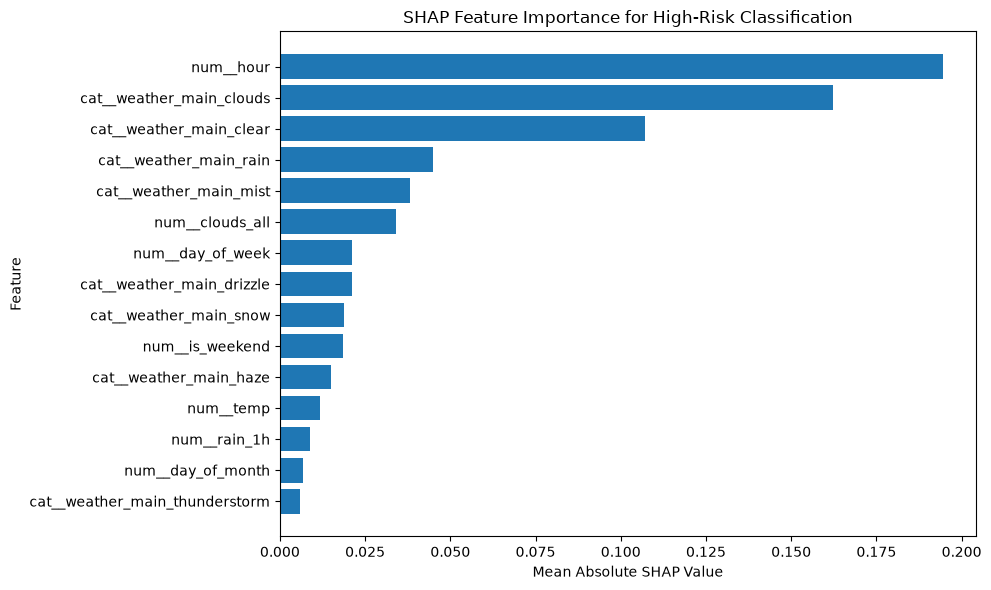

SHAP plot saved successfully.


In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_shap = shap_importance_df.head(15).sort_values(
    "Mean Absolute SHAP"
)

plt.barh(
    top_shap["Feature"],
    top_shap["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance for High-Risk Classification")

plt.tight_layout()

plt.savefig(
    "reports/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP plot saved successfully.")

In [127]:
from pathlib import Path

shap_file = Path("reports/shap_feature_importance.png")

print("Exists:", shap_file.exists())
print("Path:", shap_file.resolve())

Exists: True
Path: C:\Users\akash\Downloads\Smart_City_Traffic_Intelligence\part2_python\reports\shap_feature_importance.png


In [128]:
from pathlib import Path

processed_dir = Path("data/processed")
reports_dir = Path("reports")

required_files = {
    "Classification results": processed_dir / "classification_model_results.csv",
    "Association rules": processed_dir / "association_rules.csv",
    "MLflow results": processed_dir / "mlflow_classification_run.csv",
    "Saved classification model": processed_dir / "random_forest_classification_model.joblib",
    "Drift monitoring": processed_dir / "drift_monitoring_results.csv",
    "Fairness performance": processed_dir / "fairness_performance_results.csv",
    "Fairness prediction rates": processed_dir / "fairness_prediction_rates.csv",
    "Timing recommendations": processed_dir / "traffic_timing_recommendations.csv",
    "FastAPI evidence": reports_dir / "fastapi_test_result.txt",
    "Responsible AI report": reports_dir / "responsible_ai_fairness_report.txt",
    "Timing recommendation report": reports_dir / "traffic_timing_recommendation.txt",
    "SHAP visualization": reports_dir / "shap_feature_importance.png",
}

print("=== PART 3 REQUIREMENT CHECK ===\n")

all_present = True

for name, path in required_files.items():
    status = path.exists()
    print(f"{'✓' if status else '✗'} {name}: {path}")
    
    if not status:
        all_present = False

print("\n" + "=" * 40)

if all_present:
    print("✓ ALL REQUIRED PART 3 OUTPUT FILES ARE PRESENT")
else:
    print("⚠ SOME PART 3 FILES ARE MISSING")

=== PART 3 REQUIREMENT CHECK ===

✓ Classification results: data\processed\classification_model_results.csv
✓ Association rules: data\processed\association_rules.csv
✓ MLflow results: data\processed\mlflow_classification_run.csv
✓ Saved classification model: data\processed\random_forest_classification_model.joblib
✓ Drift monitoring: data\processed\drift_monitoring_results.csv
✓ Fairness performance: data\processed\fairness_performance_results.csv
✓ Fairness prediction rates: data\processed\fairness_prediction_rates.csv
✓ Timing recommendations: data\processed\traffic_timing_recommendations.csv
✓ FastAPI evidence: reports\fastapi_test_result.txt
✓ Responsible AI report: reports\responsible_ai_fairness_report.txt
✓ Timing recommendation report: reports\traffic_timing_recommendation.txt
✓ SHAP visualization: reports\shap_feature_importance.png

✓ ALL REQUIRED PART 3 OUTPUT FILES ARE PRESENT


In [129]:
from pathlib import Path

requirements_path = Path("../requirements.txt")

print(requirements_path.read_text())

pandas
numpy
scipy
matplotlib
scikit-learn
joblib
shap
fastapi
uvicorn
pydantic
mlflow
mlxtend



In [130]:
from pathlib import Path

requirements = """pandas
numpy
scipy
matplotlib
scikit-learn
joblib
shap
fastapi
uvicorn
pydantic
mlflow
mlxtend
"""

Path("../requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("requirements.txt updated successfully.")

requirements.txt updated successfully.


In [131]:
print(Path("../requirements.txt").read_text())

pandas
numpy
scipy
matplotlib
scikit-learn
joblib
shap
fastapi
uvicorn
pydantic
mlflow
mlxtend



In [132]:
from pathlib import Path

lines = [
    "# Smart City Traffic Intelligence",
    "",
    "End-to-end capstone project using the Metro Interstate Traffic Volume dataset.",
    "",
    "The project covers data analytics, Python data processing, machine learning,",
    "deep learning, explainable AI, MLOps, deployment, monitoring, responsible AI,",
    "and traffic timing recommendations.",
    "",
    "## Project Structure",
    "",
    "- data/Metro_Interstate_Traffic_Volume.csv",
    "- part1_sql/",
    "- part1_powerbi/",
    "- part2_python/",
    "- part3_machine_learning/",
    "- reports/",
    "- requirements.txt",
    "- README.md",
    "- Smart_City_Traffic_Intelligence_Final_Report.docx",
    "",
    "## Environment",
    "",
    "Python 3.10+ is recommended.",
    "",
    "Create the environment:",
    "",
    "python -m venv .venv",
    "",
    "Install dependencies:",
    "",
    "pip install -r requirements.txt",
    "",
    "## Part 1 - SQL and Power BI",
    "",
    "Part 1 includes SQLite analysis and a Power BI dashboard.",
    "",
    "The SQL analysis covers annual traffic totals, holiday temperature analysis,",
    "traffic statistics, Pearson correlation, probability, conditional probability,",
    "independence analysis and odds ratio analysis.",
    "",
    "SQL files:",
    "",
    "- part1_sql/traffic_analysis.db",
    "- part1_sql/analysis.sql",
    "- part1_sql/sql_results.txt",
    "",
    "Power BI dashboard:",
    "",
    "- part1_powerbi/traffic_dashboard.pbix",
    "",
    "The dashboard includes traffic KPIs, hourly traffic, daily traffic,",
    "weather analysis, temperature analysis and slicers.",
    "",
    "## Part 2 - Python Data Pipeline",
    "",
    "The main pipeline is part2_python/pipeline.py.",
    "",
    "The pipeline performs:",
    "",
    "1. Schema validation",
    "2. Datetime parsing",
    "3. Missing holiday handling",
    "4. Duplicate removal",
    "5. Invalid temperature handling",
    "6. Monthly median temperature imputation",
    "7. Weather standardisation",
    "8. Time-based feature engineering",
    "9. Processed dataset export",
    "10. Logging",
    "",
    "Final processed data:",
    "",
    "- 48,187 rows",
    "- 18 columns",
    "- 0 missing values",
    "- 0 duplicate rows",
    "",
    "CLI commands:",
    "",
    "python part2_python/pipeline.py validate --input data/Metro_Interstate_Traffic_Volume.csv",
    "",
    "python part2_python/pipeline.py clean --input data/Metro_Interstate_Traffic_Volume.csv --output part2_python/data/processed/cli_cleaned_traffic.csv",
    "",
    "python part2_python/pipeline.py run --input data/Metro_Interstate_Traffic_Volume.csv --output part2_python/data/processed/final_pipeline_output.csv",
    "",
    "Log file:",
    "",
    "part2_python/reports/logs/pipeline.log",
    "",
    "## Part 3 - Machine Learning",
    "",
    "Because no accident dataset was supplied, a proxy high-risk label was created",
    "using congestion and selected severe-weather conditions.",
    "",
    "Congestion categories:",
    "",
    "- Low",
    "- Moderate",
    "- High",
    "- Severe",
    "",
    "Selected severe-weather categories:",
    "",
    "- rain",
    "- thunderstorm",
    "- fog",
    "- mist",
    "- snow",
    "- haze",
    "",
    "The proxy label must not be interpreted as actual accident prediction.",
    "",
    "### Classification",
    "",
    "Models:",
    "",
    "- Logistic Regression",
    "- Random Forest",
    "- Neural Network",
    "",
    "Metrics:",
    "",
    "- Accuracy",
    "- Precision",
    "- Recall",
    "- F1",
    "- ROC AUC",
    "",
    "Output: part2_python/data/processed/classification_model_results.csv",
    "",
    "### Regression",
    "",
    "Models:",
    "",
    "- Linear Regression",
    "- Random Forest Regression",
    "",
    "Metrics:",
    "",
    "- MAE",
    "- R-squared",
    "",
    "### Unsupervised Learning",
    "",
    "K-means clustering and Apriori association-rule mining were performed.",
    "",
    "Output: part2_python/data/processed/association_rules.csv",
    "",
    "### Explainable AI",
    "",
    "SHAP was used for Random Forest feature importance.",
    "",
    "Output: part2_python/reports/shap_feature_importance.png",
    "",
    "### MLOps",
    "",
    "MLflow was used to track the Random Forest classification experiment.",
    "",
    "Output: part2_python/data/processed/mlflow_classification_run.csv",
    "",
    "## Deployment",
    "",
    "A FastAPI application is provided in part2_python/app.py.",
    "",
    "The saved model is:",
    "",
    "part2_python/data/processed/random_forest_classification_model.joblib",
    "",
    "FastAPI test evidence:",
    "",
    "part2_python/reports/fastapi_test_result.txt",
    "",
    "## Monitoring",
    "",
    "Drift monitoring was performed using the Kolmogorov-Smirnov test.",
    "",
    "Output: part2_python/data/processed/drift_monitoring_results.csv",
    "",
    "The analysis produced 8 PASS results and 0 ALERT results.",
    "",
    "This is an internal historical train/test stability check and not proof of",
    "production drift behaviour.",
    "",
    "## Responsible AI",
    "",
    "The project considers fairness across weekday and weekend groups, uneven",
    "model performance, proxy-label limitations, dataset coverage limitations,",
    "and potential consequences of incorrect predictions.",
    "",
    "Outputs:",
    "",
    "- fairness_performance_results.csv",
    "- fairness_prediction_rates.csv",
    "- responsible_ai_fairness_report.txt",
    "",
    "The model should not be treated as definitive evidence of accident risk.",
    "",
    "## Traffic Timing Recommendation",
    "",
    "Because the dataset represents a single corridor, the recommendation focuses",
    "on travel timing rather than route selection.",
    "",
    "Historical traffic was substantially lower during early-morning weekday",
    "periods, particularly around 2 AM to 4 AM.",
    "",
    "The lowest observed average traffic was approximately 302 vehicles per hour",
    "at 2 AM on weekdays.",
    "",
    "This is a historical traffic-pattern recommendation, not a guarantee of",
    "road safety. Weather and real-world operating conditions should still be considered.",
    "",
    "Recommendation outputs:",
    "",
    "- traffic_timing_recommendations.csv",
    "- traffic_timing_recommendation.txt",
    "",
    "## Reproducibility",
    "",
    "Install dependencies using requirements.txt.",
    "",
    "The main reproducible pipeline is part2_python/pipeline.py.",
    "",
    "The analysis notebook is part2_python/part2_traffic_pipeline.ipynb.",
    "",
    "Processed datasets and model outputs are stored under part2_python/data/processed/.",
    "",
    "## Git and Security",
    "",
    "Use incremental commits during development.",
    "",
    "Never commit passwords, API keys, authentication tokens or other secrets."
]

Path("../README.md").write_text("\n".join(lines), encoding="utf-8")

print("README.md updated successfully.")

README.md updated successfully.


In [133]:
from pathlib import Path

readme_path = Path("../README.md")

print("Exists:", readme_path.exists())
print("Size:", readme_path.stat().st_size, "bytes")

Exists: True
Size: 5547 bytes
